In [1]:
# https://www.kaggle.com/competitions/the-defected-nuts-aicc-round-1-2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
import torchvision.transforms.functional as TF
import base64
from PIL import Image
from sklearn.model_selection import train_test_split
from IPython.display import clear_output
from torchvision import models
from scipy.ndimage import gaussian_filter

In [2]:
train_dir = '/kaggle/input/the-defected-nuts-aicc-round-1-2/data/train'
test_dir = '/kaggle/input/the-defected-nuts-aicc-round-1-2/data/test'

train_len = len(os.listdir(train_dir))
test_len = len(os.listdir(test_dir))

train_len, test_len

(431, 70)

In [3]:
def visualize_images(paths_grid):
    W, H = len(paths_grid), len(paths_grid[0])
    plt.figure(figsize=(W*2, H*2))
    
    for i in range(W):
        for j in range(H):
            plt.subplot(W, H, i*H+j+1)
            plt.imshow(Image.open(paths_grid[i][j]))
            plt.title(paths_grid[i][j].split('/')[-1])
            plt.xticks([])
            plt.yticks([])

    plt.tight_layout()
    plt.show()

In [4]:
W, H = 3, 3
train_paths_grid = [[os.path.join(train_dir, f'{np.random.randint(1, train_len+1)}.png') for j in range(H)] for i in range(W)]
test_paths_grid = [[os.path.join(test_dir, f'{np.random.randint(1, test_len+1)}.png') for j in range(H)] for i in range(W)]

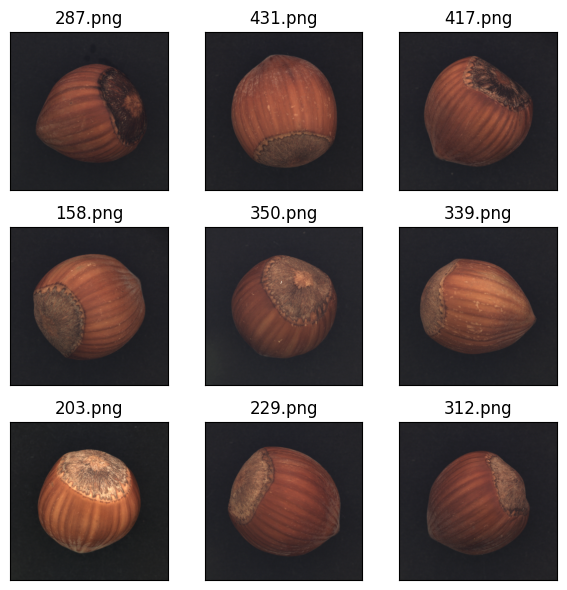

In [5]:
visualize_images(train_paths_grid)

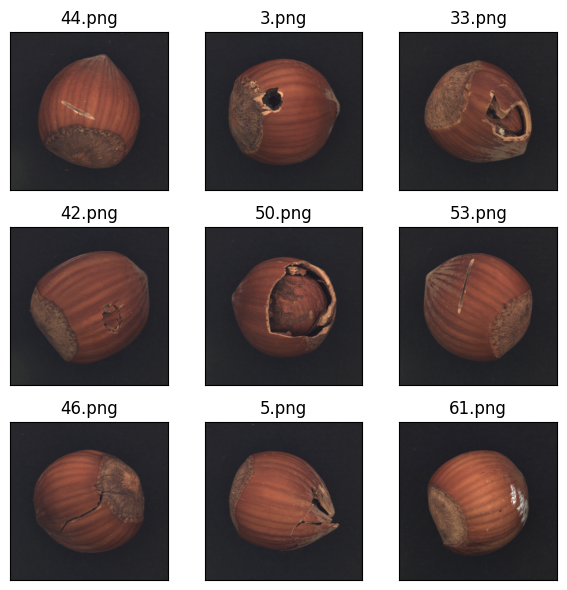

In [6]:
visualize_images(test_paths_grid)

In [7]:
train_paths = [os.path.join(train_dir, p) for p in sorted(os.listdir(train_dir), key=lambda x: int(x.split('.')[0]))]
test_paths = [os.path.join(test_dir, p) for p in sorted(os.listdir(test_dir), key=lambda x: int(x.split('.')[0]))]

In [8]:
class NutDataset(Dataset):
    def __init__(self, paths, transforms=None):
        self.paths = paths
        self.transforms = transforms

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx])
        if self.transforms is not None:
            img = self.transforms(img)
        return img

class ExactRotation:
    def __init__(self, angles=[0, 90, 180, 270]):
        self.angles = angles

    def __call__(self, img):
        angle = np.random.choice(self.angles).item()
        return TF.rotate(img, angle)

train_transforms = v2.Compose([
    # v2.Resize((256, 256)),
    # ExactRotation(angles=[0, 90, 180, 270]),
    # v2.RandomRotation(degrees=(0, 360), fill=(36, 36, 41)),
    # v2.RandomHorizontalFlip(0.5),
    # v2.RandomVerticalFlip(0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = v2.Compose([
    # v2.Resize((256, 256)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_ds = NutDataset(train_paths, transforms=train_transforms)
test_ds = NutDataset(test_paths, transforms=test_transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(test_loader)

(14, 3)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [10]:
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, up_to=-3):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.eval()
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        x  = self.stem(x)
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)
        sz = f3.shape[2:]
        f1 = F.interpolate(f1, size=sz, mode="bilinear", align_corners=False)
        f2 = F.interpolate(f2, size=sz, mode="bilinear", align_corners=False)
        return torch.cat([f1, f2, f3], dim=1).permute(0, 2, 3, 1)

model = ResNetFeatureExtractor().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 241MB/s]


In [11]:
@torch.no_grad()
def extract_patch_embeddings(model, loader, device):
    embeddings = []

    for X in tqdm(loader, desc='DataLoader'):
        emb = model(X.to(device))
        embeddings.append(emb.cpu())
    
    embeddings = torch.cat(embeddings)
    return embeddings

In [12]:
train_embeddings = extract_patch_embeddings(model, train_loader, device)
train_embeddings.shape

DataLoader:   0%|          | 0/14 [00:00<?, ?it/s]

torch.Size([431, 64, 64, 448])

In [13]:
bank_ratio = 0.1
num_patches = train_embeddings.numel() // train_embeddings.shape[-1]
n_keep = int(bank_ratio * num_patches)

bank = train_embeddings.reshape(-1, train_embeddings.shape[-1])[torch.randperm(num_patches)[:n_keep]].to(device)
bank.shape

torch.Size([176537, 448])

In [14]:
test_embeddings = extract_patch_embeddings(model, test_loader, device)
test_embeddings.shape

DataLoader:   0%|          | 0/3 [00:00<?, ?it/s]

torch.Size([70, 64, 64, 448])

In [15]:
def process_test_sample(sample, sigma=1.0):
    H, W, D = sample.shape
    res = torch.cdist(sample.reshape(-1, sample.shape[-1]).to(device), bank).min(dim=1).values.cpu().reshape(sample.shape[0], sample.shape[1])
    res = F.interpolate(res.unsqueeze(0).unsqueeze(0), size=(1024, 1024), mode='bilinear', align_corners=False).squeeze()
    res = gaussian_filter(res.numpy(), sigma=sigma).squeeze()
    return res

anomaly_maps = np.zeros((len(test_embeddings), 1024, 1024))
for i in tqdm(range(len(test_embeddings))):
    anomaly_maps[i] = process_test_sample(test_embeddings[i])

  0%|          | 0/70 [00:00<?, ?it/s]

In [16]:
anomaly_min, anomaly_max = anomaly_maps.min(), anomaly_maps.max()
anomaly_maps = (anomaly_maps - anomaly_min) / (anomaly_max - anomaly_min + 1e-9)
anomaly_maps = (anomaly_maps * 255).astype(np.uint8)

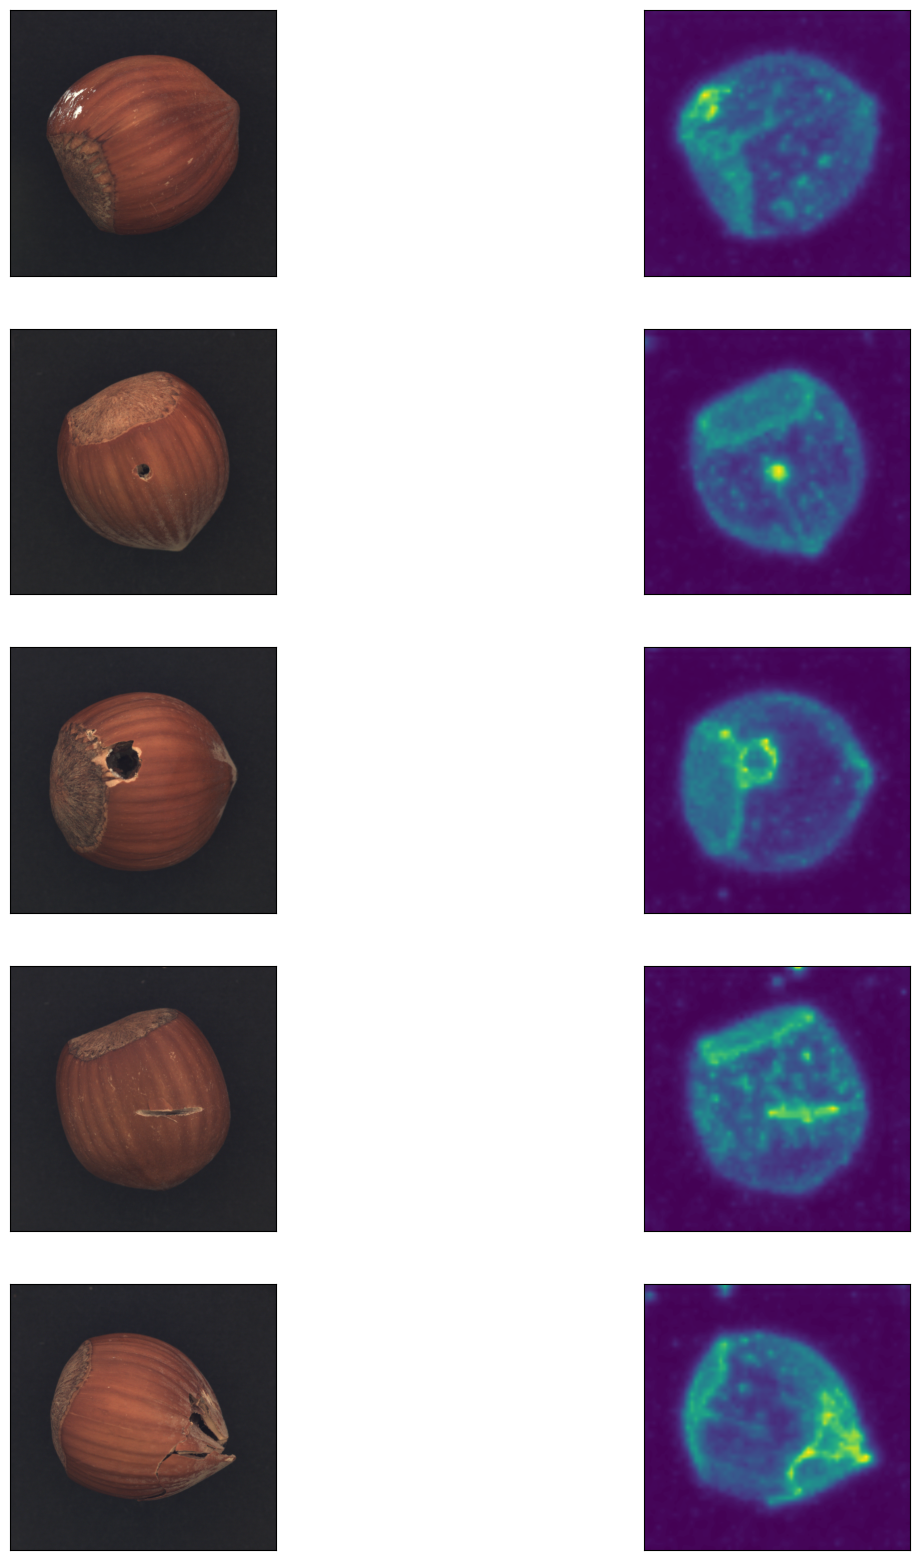

In [17]:
def plot_anomaly_examples(indices):
    plt.figure(figsize=(15, 4*len(indices)))
    for i, idx in enumerate(indices):
        plt.subplot(len(indices), 2, i*2+1)
        plt.imshow(Image.open(test_paths[idx]))
        plt.xticks([])
        plt.yticks([])

        plt.subplot(len(indices), 2, i*2+2)
        plt.imshow(anomaly_maps[idx])
        plt.xticks([])
        plt.yticks([])
        
    plt.show()

plot_anomaly_examples(range(5))

In [18]:
assert anomaly_maps.shape == (70, 1024, 1024), f"Wrong shape: {anomaly_maps.shape}"
assert anomaly_maps.dtype == np.uint8, f"Wrong dtype: {anomaly_maps.dtype}"

df = pd.DataFrame(columns=["data"])

for i, anomaly_map in enumerate(tqdm(anomaly_maps)):
    df.loc[i] = base64.b85encode(anomaly_map.tobytes()).decode("ascii")

df = df.reset_index()
df.columns = ["id", "data"]
df.to_csv("/kaggle/working/submission.csv", index=False)

print("✓ submission.csv written")

  0%|          | 0/70 [00:00<?, ?it/s]

✓ submission.csv written
